<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

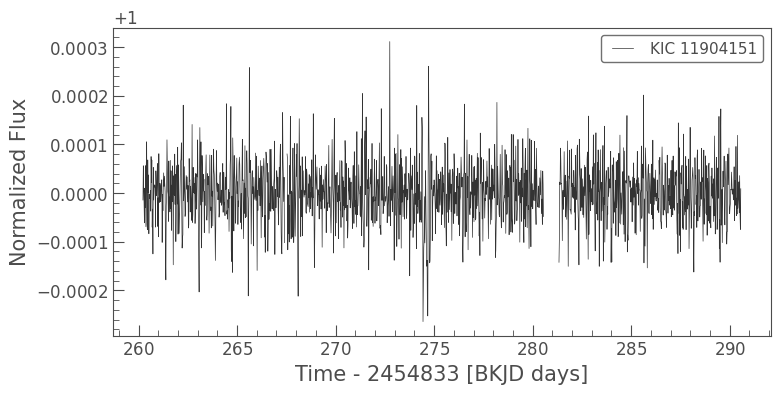

In [1]:
##pour etre sur que les graphiques s'affichent
%matplotlib inline
import warnings
warnings.filterwarnings('ignore', category=UserWarning, append=True)
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

#on cherche les données de la nasa sur Kepler-10
search_result = lk.search_lightcurve("Kepler-10", quarter=3)

light_curve = search_result[0].download()
#On définie un temps de 0.00075jour (valeur ajustée pour avoir un résultat le plus proche possible de celui de la planète) pour faire la moyenne des points avec le fonction .bin() afin de néttoyer le graphique
time_bin_size=0.00075

#lisse la courbe pour corriger les erreurs humaines mais ne lisse pas les transits
## remove nans retire les points sans valeurs
light_curve_flat = light_curve.flatten(window_length=401).remove_nans()
lc_clean = light_curve_flat.bin(time_bin_size*25)
lc_clean.plot()



<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

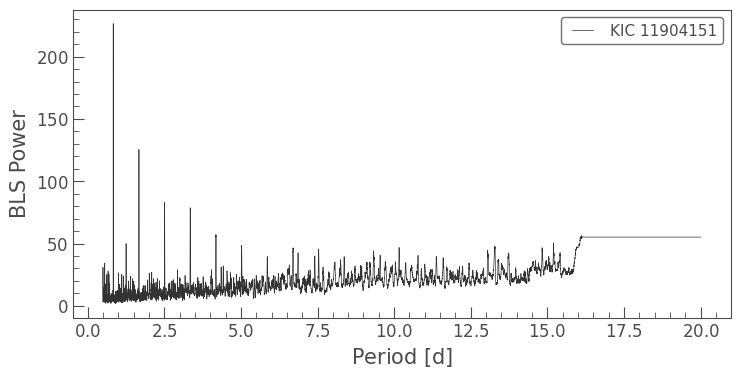

In [2]:
# On va travailler sur 10000 instants entre 0.5 et 20 jours sur notre courbe
periods = np.linspace(0.5,20,10000)

#On utilise l'algorithme Bls pour détecter une planète
bls = light_curve_flat.to_periodogram(method='bls', period = periods)

bls.plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

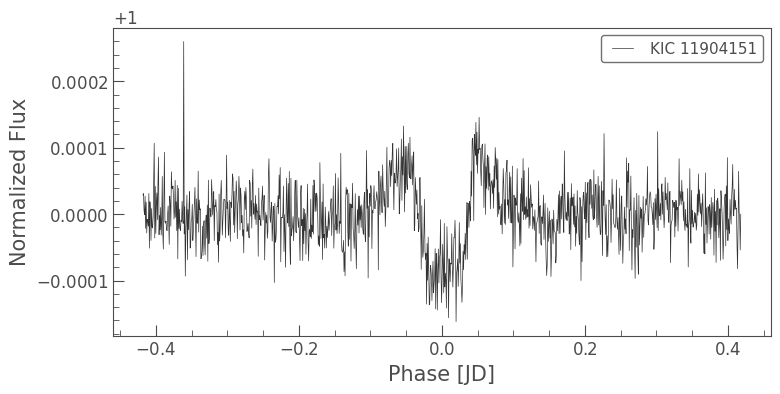

In [3]:
#on creer la phase avec la periode et le moment de début puis on affiche
phase = light_curve_flat.fold(period = 0.837, epoch_time= bls.transit_time_at_max_power ).bin(time_bin_size) 
phase.plot()

In [4]:
##On applique la formule 
picBas = 1 - np.min(phase.flux)
    
rayonKepler = round(np.sqrt(picBas)*696342,1)

rayonKeplerRayonTerrestre = round(rayonKepler/6371,1)

print(f"Le rayon de Kepler-10b est de {rayonKepler}Km soit {rayonKeplerRayonTerrestre} rayons terrestres !")

Le rayon de Kepler-10b est de 8858.7Km soit 1.4 rayons terrestres !
